In [1]:
# 필요한 라이브러리들 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# csv를 읽어와서 Pandas DataFrame으로 저장

data = pd.read_csv("./data/2000_2001_hitter.csv")
data2 = pd.read_csv("./data/2002_2013_hitter.csv")
data3 = pd.read_csv("./data/2014_hitter.csv")

# 여러 데이터프레임을 리스트 [] 로 묶어서 전달해야 합니다.
df_combined = pd.concat([data, data2, data3], axis=0)

# 인덱스가 중복될 수 있으므로 초기화해주는 것이 깔끔합니다.
df_combined = df_combined.reset_index(drop=True)

# 확인
df_combined.sample(5)

,YrPlayer,Year,Rank,Player,Team,AVG,G,PA,AB,H,...,TA,RC,RC/27,wOBA,XR,R,SAC,MH,RISP,PH-BA
578,2013전준우,2013,33,전준우,롯데,0.275,128,537,455,125,...,0.719547,66.404171,4.912089,0.333227,66.704,65.0,5.0,34.0,0.316,0.000
486,2011강민호,2011,18,강민호,롯데,0.289,124,506,450,130,...,0.781977,73.939091,5.786538,0.366746,71.022,63.0,0.0,39.0,0.257,0.000
128,2002박진만,2002,40,박진만,현대,0.219,126,466,401,88,...,0.608025,46.727897,3.743778,0.297884,47.590,47.0,9.0,18.0,0.206,0.000
467,2010김원섭,2010,44,김원섭,KIA,0.238,111,428,353,84,...,0.671429,46.743738,4.249431,0.311556,46.786,43.0,16.0,22.0,0.194,0.222
322,2007박재홍,2007,25,박재홍,SK,0.280,115,400,347,97,...,0.828244,61.262500,6.126250,0.357697,61.384,53.0,1.0,22.0,0.247,0.333


In [ ]:
#파일을 합치기


,YrPlayer,Year,Rank,Player,Team,AVG,G,PA,AB,H,...,TA,RC,RC/27,wOBA,XR,R,SAC,MH,RISP,PH-BA
0,2000박종호,2000,1,박종호,현대,0.340,121,541,441,150,...,0.976667,100.354529,8.286154,0.400138,92.804,NaN,NaN,NaN,NaN,NaN
1,2000김동주,2000,2,김동주,두산,0.339,127,539,469,159,...,1.063830,115.473840,9.306847,0.431993,105.000,NaN,NaN,NaN,NaN,NaN
2,2000브리또,2000,3,브리또,SK,0.338,103,452,405,137,...,0.931655,86.204956,8.224501,0.400969,77.820,NaN,NaN,NaN,NaN,NaN
3,2000송지만,2000,4,송지만,한화,0.338,120,530,468,158,...,1.110092,119.916981,9.811389,0.436688,107.594,NaN,NaN,NaN,NaN,NaN
4,2000데이비스,2000,5,데이비스,한화,0.334,107,458,419,140,...,0.923588,82.605677,7.125729,0.394586,80.284,NaN,NaN,NaN,NaN,NaN


In [6]:
# 변수 선택
X = df_combined[['HR','OPS','ISO','SECA','TA','RC','RC/27','wOBA','XR']]
y = df_combined['YrPlayer']

print(X.shape, y.shape)
X.head()
y.head()
print(df_combined)

(649, 9) (649,)
      YrPlayer  Year  Rank Player Team    AVG    G   PA   AB    H  ...  \
0     2000박종호   2000     1   박종호   현대   0.340  121  541  441  150  ...   
1     2000김동주   2000     2   김동주   두산   0.339  127  539  469  159  ...   
2     2000브리또   2000     3   브리또   SK   0.338  103  452  405  137  ...   
3     2000송지만   2000     4   송지만   한화   0.338  120  530  468  158  ...   
4    2000데이비스   2000     5  데이비스   한화   0.334  107  458  419  140  ...   
..         ...   ...   ...    ...  ...    ...  ...  ...  ...  ...  ...   
644    2014이범호  2014    51    이범호  KIA  0.269  105  406  350   94  ...   
645    2014모창민  2014    52    모창민   NC  0.263  122  468  419  110  ...   
646    2014오지환  2014    53    오지환   LG  0.262  113  464  397  104  ...   
647    2014조동화  2014    54    조동화   SK  0.262  125  522  443  116  ...   
648    2014김재호  2014    55    김재호   두산  0.252  122  421  341   86  ...   

           TA          RC     RC/27      wOBA       XR     R   SAC    MH  \
0    0.976667  100.

In [7]:
# 데이터 분포 확인(박스플롯)
sns.boxplot(X,y)
plt.show()

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 were given

In [9]:
# 데이터 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_combined_scaler = scaler.fit_transform(X)
print(df_combined_scaler)

[[-0.3731278   0.97614887 -0.07422939 ...  1.20484091  1.11880719
   1.21433377]
 [ 1.81506444  1.89711625  1.67989079 ...  1.75823146  1.89486616
   1.85744936]
 [ 0.14787035  1.10761611  0.61991005 ...  1.1714146   1.13904003
   0.42420225]
 ...
 [-0.58152706 -0.42233048 -0.05169927 ... -0.32541846 -0.43538549
  -0.33597768]
 [-1.20672484 -1.46085838 -1.39601302 ... -1.37885116 -1.47288829
  -1.11957047]
 [-1.10252521 -1.28467954 -1.24146838 ... -1.19083305 -1.21125882
  -1.3345048 ]]


In [10]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수
def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

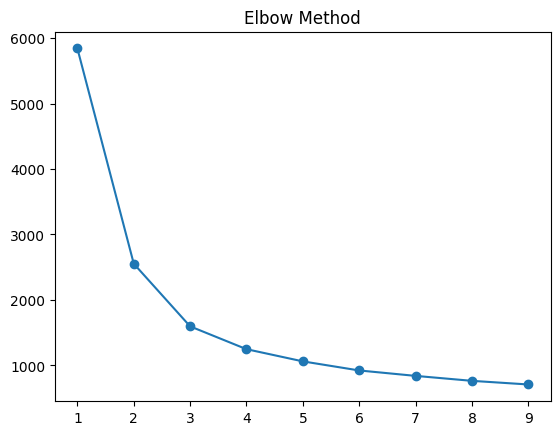

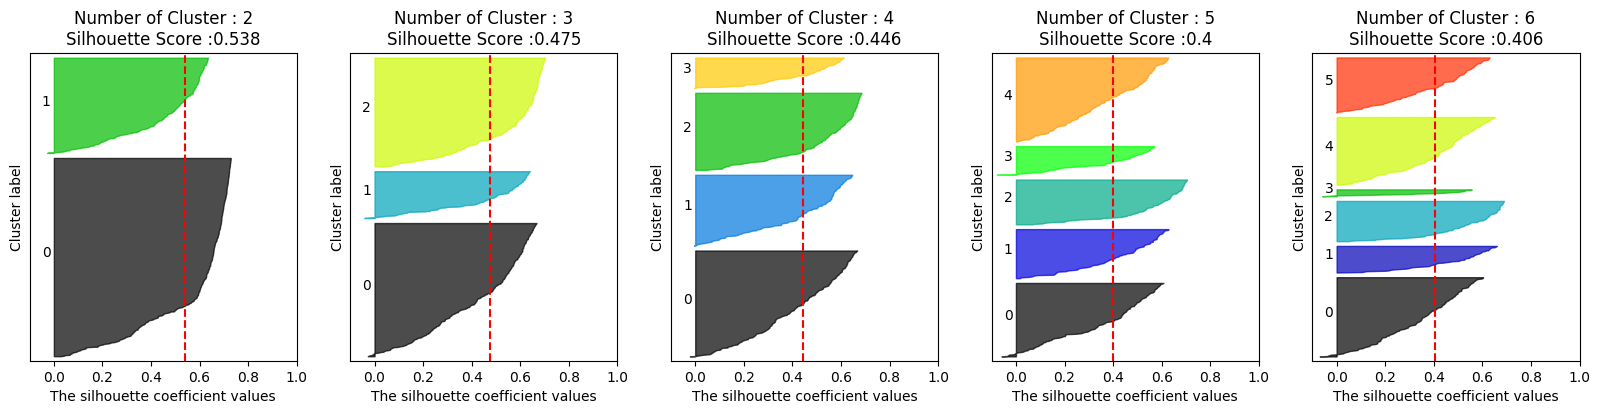

In [19]:
# --- 1. Elbow Method로 후보 확인 ---
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for n in range(1, 10):
    km = KMeans(n_clusters=n, init='k-means++', random_state=42, n_init=10)
    km.fit(df_combined_scaler)
    inertia.append(km.inertia_)

# Elbow 그래프 시각화 (어디서 꺾이는지 확인용)
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method')
plt.show()

visualize_silhouette([2,3,4,5,6], X)

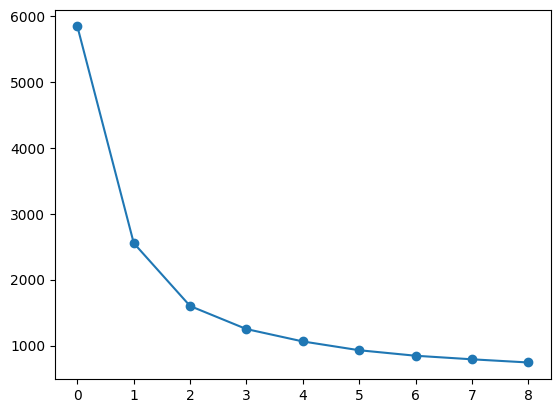

In [12]:
plt.plot(inertia, marker = 'o')
plt.show()

In [ ]:
# 엘보우 기법으로 최적의 k 찾기
3개

In [ ]:
# 군집화 결과 분석 

# 데이터프레임 생성
df = pd.DataFrame(X, columns=X.columns)
df['cluster'] = cluster
df.head()


In [ ]:
# 군집의 데이터 특징 분석
cols = df.columns[:-1]

plt.figure(figsize=(15,8))
for i, col in enumerate(cols):
    plt.subplot(2,4,i+1)
    sns.boxplot(data=df, y=col, hue='cluster', palette='muted')
    plt.title(col)
plt.tight_layout()

In [ ]:
# 데이터프레임에 개별 데이터 실루엣 계수 컬럼 추가

In [ ]:
# 잘못 군집화 된 클러스터
df.loc[df['silhouette']<0]

In [ ]:
# 클러스터 별 중심 player

In [ ]:
# 전체 주성분 계산

from sklearn.decomposition import PCA



(649, 8)

In [ ]:
# 컬럼별 설명된 분산 비율 확인
explained_variance = pca.explained_variance_ratio_
explained_variance

array([9.05145728e-01, 5.06261666e-02, 2.18885403e-02, 1.84561022e-02,
       2.99299164e-03, 5.56239341e-04, 1.83919162e-04, 1.50312428e-04])

In [ ]:
# 누적분산 확인
cumulative_variance = explained_variance.cumsum()
cumulative_variance

array([0.90514573, 0.95577189, 0.97766044, 0.99611654, 0.99910953,
       0.99966577, 0.99984969, 1.        ])

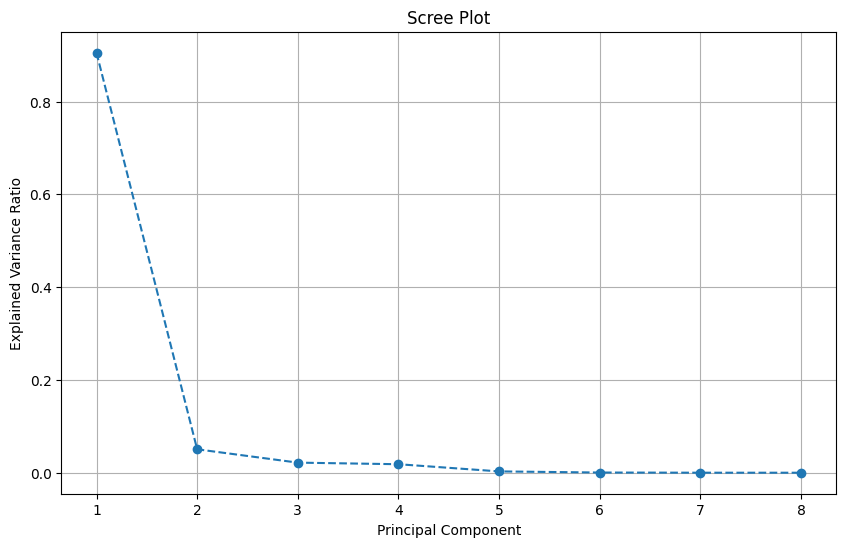

In [14]:
# Plot Scree Chart
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(np.arange(1, len(explained_variance) + 1, 1))
plt.grid()
plt.show()

In [ ]:
# 최적의 주성분 개수 선택 (예: 95% 이상의 분산을 설명하는 최소 주성분 개수)


1

In [ ]:
# 2개의 주성분으로 변환하기 
from sklearn.decomposition import PCA

# PCA 수행



array([[ 2.48864775, -1.29871071],
       [ 4.8638416 , -0.32843484],
       [ 2.05850718, -0.4397998 ],
       ...,
       [-0.3971905 ,  0.69084294],
       [-3.94087277, -0.42488303],
       [-3.33227219,  0.22550401]])

In [21]:
# PCA 설명된 분산 비율 출력


array([0.90514573, 0.05062617])

In [18]:
# pc1, pc2로 결과 데이터프레임 생성 


,principal component 1,principal component 2
0,2.488648,-1.298711
1,4.863842,-0.328435
2,2.058507,-0.439800
3,5.544865,-0.087107
4,2.134990,0.387255
...,...,...
644,1.024438,1.383975
645,-1.873179,0.821719
646,-0.397191,0.690843
647,-3.940873,-0.424883


In [ ]:
# 주성분으로 군집화
k = 4



In [ ]:
# 군집 결과 시각화

In [ ]:
# PCA를 전후 군집 결과 비교